Purpose: Make GDE figures (HybridExpress results) for clock, CA-cycle, N metabolism, and photorespiration (PhotResp) genes.<br>
Author: Anna Pardo<br>
Date initiated: Aug. 12, 2026

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import os

In [2]:
# load results dataframe
res = pd.read_csv("./hybexp_top30pct_partitiongenes_bygttreat.txt",sep="\t",header="infer")
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [3]:
# split genotype & treatment info
gtt = res["genotype_treat"].str.split("_",expand=True)
gtt.rename(columns={0:"genotype",1:"treat"},inplace=True)
res = pd.concat([res,gtt],axis=1)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D


In [4]:
physcat = json.load(open("../../physiology/physiological_categories_from_TA.json"))

In [5]:
res["phys"] = res["genotype"].map(physcat)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D,18,D,C3+CAM
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D,18,D,C3+CAM
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D,18,D,C3+CAM
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D,18,D,C3+CAM
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D,18,D,C3+CAM


In [6]:
# load pathway annotation
pathann = pd.read_csv("/home/leviathan22/yucca-genomics/gene_annotations/pathways_annotation_withsyntelogs.csv",sep=",",
                     header="infer")
pathann.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique,syntelogID
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1,recip_syn2455
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2,recip_syn28929
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1,recip_syn2455
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2,recip_syn13442
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3,recip_syn28929


In [7]:
# replace ELD_P1 with ELD_Ya, and ELD_P2 with ELD_Yf
classes = {}
for c in res["Class"].unique():
    if c=="ELD_P1":
        classes[c] = "ELD_Ya"
    elif c=="ELD_P2":
        classes[c] = "ELD_Yf"
    else:
        classes[c] = c
        
res["Class"] = res["Class"].map(classes)

In [33]:
# function for converting to wide data
def to_wide_data(c,data):
    sub = data[data["Class"]==c]
    wide = pd.pivot(sub,index=["syntelog_name"],columns="phystreat",values="genotype")
    wide.fillna(0,inplace=True)
    return wide

In [10]:
# custom colormap for plotting
custompal = {
    "C3+CAM_W":"skyblue",
    "facultative CAM_W":"royalblue",
    "CAM_W":"navy",
    "C3+CAM_D":"coral",
    "facultative CAM_D":"orangered",
    "CAM_D":"saddlebrown"
}
cmap = LinearSegmentedColormap.from_list("custom",list(custompal.values()))

In [12]:
pathann.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique,syntelogID
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1,recip_syn2455
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2,recip_syn28929
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1,recip_syn2455
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2,recip_syn13442
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3,recip_syn28929


In [22]:
# rename syntelogs in pathann
synrename = {}
for s in pathann["syntelogID"].unique():
    df = pathann[pathann["syntelogID"]==s].sort_values(by="subgenome",ascending=True)
    if len(df.index)==1:
        synrename[s] = df.iloc[0,4]
    else:
        yaid = df.iloc[0,4].strip().split("_")
        yfid = df.iloc[1,4].strip().split("_")
        if len(yaid)==3:
            nya = yaid[2]
        else:
            nya = "1"
        if len(yfid)==3:
            nyf = yfid[2]
        else:
            nyf = "1"
            
        if nya!=nyf:
            synrename[s] = df.iloc[0,1]+"_"+nya+"/"+nyf
        else:
            synrename[s] = df.iloc[0,1]+"_"+nya

In [23]:
pathann["syntelog_name"] = pathann["syntelogID"].map(synrename)
pathann.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique,syntelogID,syntelog_name
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1,recip_syn2455,PGP_1
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2,recip_syn28929,PGP_2/3
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1,recip_syn2455,PGP_1
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2,recip_syn13442,Yf_PGP_2
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3,recip_syn28929,PGP_2/3


In [25]:
# add pathway info to results
respath = res.rename(columns={"Gene":"syntelogID"}).merge(pathann[["syntelogID","syntelog_name","gene_family","Pathway"]].drop_duplicates())

In [26]:
respath.head()

,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys,syntelog_name,gene_family,Pathway
0,recip_syn11445,1,ADD,0.312386,-1.610126,18_D,18,D,C3+CAM,NAD-MDH-cp_3,NAD-MDH-cp,CAM
1,recip_syn11445,1,ADD,0.496111,-1.427881,2AB_D,2AB,D,C3+CAM,NAD-MDH-cp_3,NAD-MDH-cp,CAM
2,recip_syn11445,1,ADD,0.368034,-1.552970,1AB_D,1AB,D,C3+CAM,NAD-MDH-cp_3,NAD-MDH-cp,CAM
3,recip_syn11445,1,ADD,0.557879,-1.360456,19_D,19,D,C3+CAM,NAD-MDH-cp_3,NAD-MDH-cp,CAM
4,recip_syn11445,9,ELD_Ya,0.190305,-1.724813,G_D,G,D,facultative CAM,NAD-MDH-cp_3,NAD-MDH-cp,CAM


In [34]:
respath["phystreat"] = respath["phys"]+"_"+respath["treat"]

In [27]:
len(respath["syntelog_name"].unique())

124

In [36]:
# make a data setup function for a given pathway
def pathway_data_setup(path,data=respath):
    # subset overall data to given pathway only
    pathdf = data[data["Pathway"]==path]
    
    # summarize number of genotypes for each syntelog
    sumdf = pathdf.groupby(["syntelog_name","Class","phystreat"]).count().reset_index()[["syntelog_name","Class","phystreat",
                                                                                         "genotype"]]
    return sumdf

In [50]:
def plot_subplot(data,c,axc,axs,all_genes):
    # ensure all genes are present
    data = data.reindex(all_genes, fill_value=0)
    # reorder columns of data according to custompal order
    data = data[list(custompal.keys())]
    # reorder data by index (gene family)
    data = data.sort_index(axis=0,ascending=True)
    
    data.plot(kind="barh",ax=axs[axc],stacked=True,colormap=cmap)
    axs[axc].set_title(c,fontsize=28)
    axs[axc].tick_params(which="both",labelsize=20)
    axs[axc].set_ylabel("")
    axs[axc].set_xticks(ticks=range(0,41,5))
    

In [51]:
def plot_pathway(path,data=respath,d="./",save=True):
    # set up pathway data overall
    pathdf = pathway_data_setup(path,data)
    # set up dict of class dataframes
    classdata = {}
    for c in pathdf["Class"].unique():
        classdata[c] = to_wide_data(c,pathdf)
    # get list of all genes
    all_genes = set()
    for v in classdata.values():
        all_genes = sorted(set().union(all_genes,v.index))
    
    sns.set_theme(style="whitegrid")
    fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,21),sharex=True,sharey=True)

    plot_subplot(classdata["ADD"],"ADD",(0,0),ax,all_genes)
    ax[0,0].get_legend().remove()
    plot_subplot(classdata["ELD_Ya"],"ELD_Ya",(0,1),ax,all_genes)
    ax[0,1].get_legend().remove()
    plot_subplot(classdata["ELD_Yf"],"ELD_Yf",(0,2),ax,all_genes)
    ax[0,2].get_legend().remove()
    plot_subplot(classdata["UP"],"UP",(1,0),ax,all_genes)
    ax[1,0].get_legend().remove()
    plot_subplot(classdata["DOWN"],"DOWN",(1,1),ax,all_genes)
    ax[1,1].legend(bbox_to_anchor=(1,1),labels=["W, C3+CAM","W, facultative CAM","W, CAM",
                                           "D, C3+CAM","D, facultative CAM","Ya, CAM"],
              fontsize=14)

    ax[1,0].set_xlabel("Number of genotypes",fontsize=16)
    ax[1,1].set_xlabel("Number of genotypes",fontsize=16)

    fig.delaxes(ax[1,2])
    fig.tight_layout()

    if save:
        if not os.path.exists(d):
            os.makedirs(d)
        
        fbase = "hybexp_"+path+"_byphys_top30"
        plt.savefig(os.path.join(d,fbase+".png"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".pdf"),dpi=300,bbox_inches="tight")
        plt.savefig(os.path.join(d,fbase+".svg"),dpi=300,bbox_inches="tight")

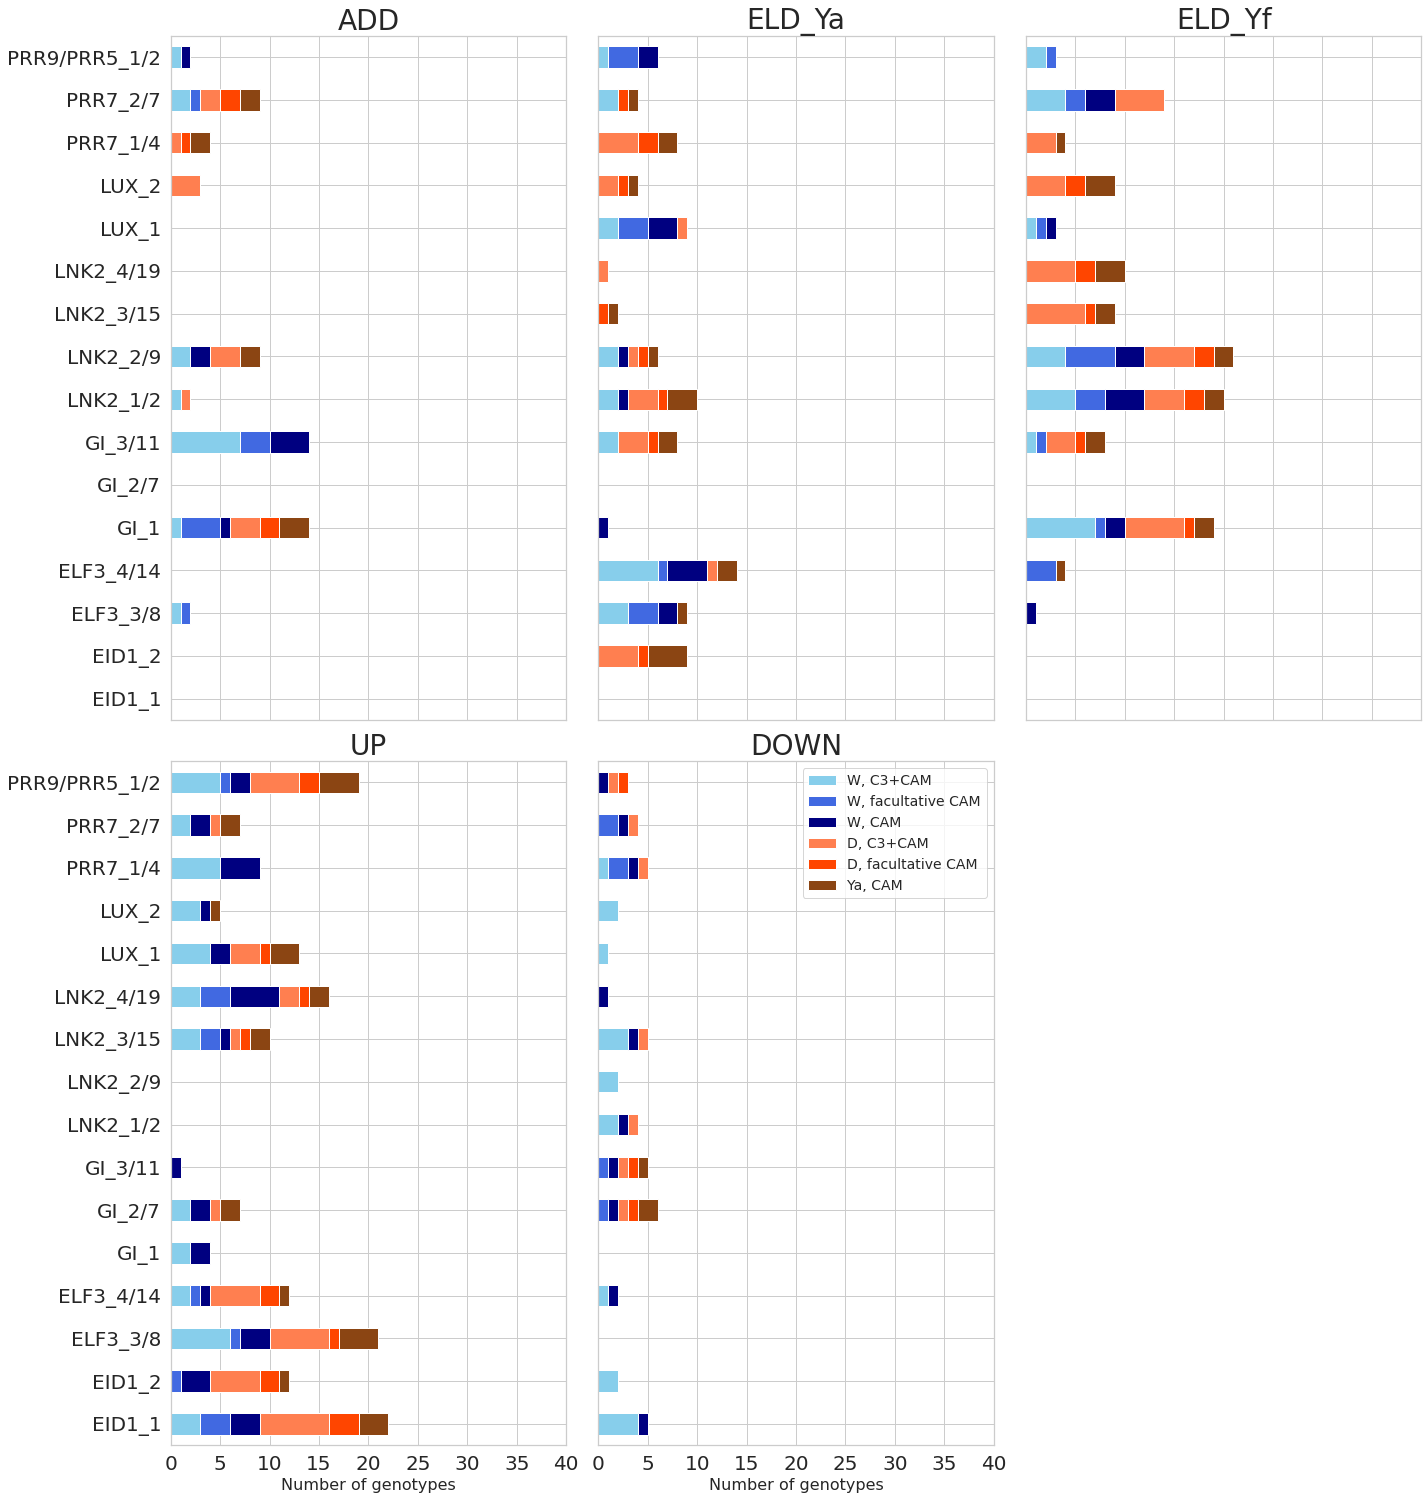

In [52]:
plot_pathway("Clock",d="./")

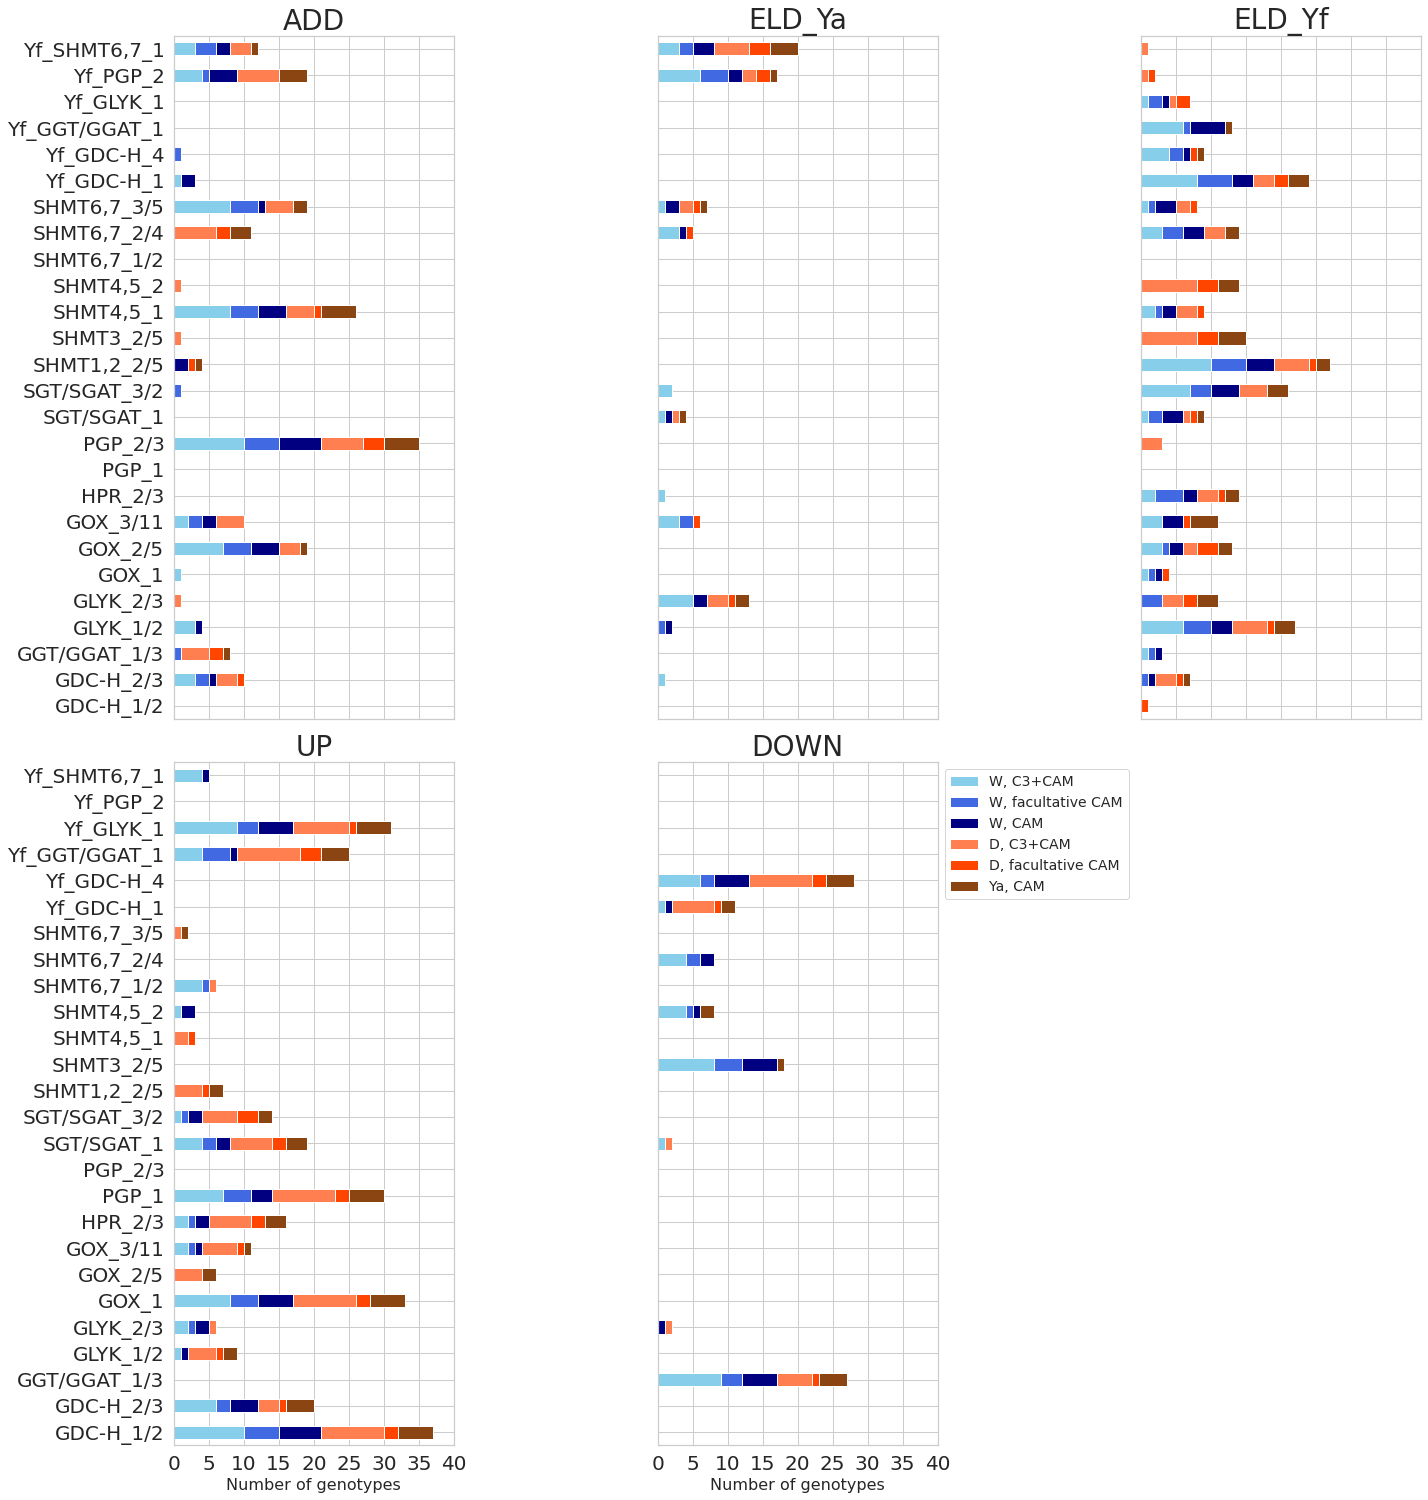

In [53]:
plot_pathway("PhotResp")

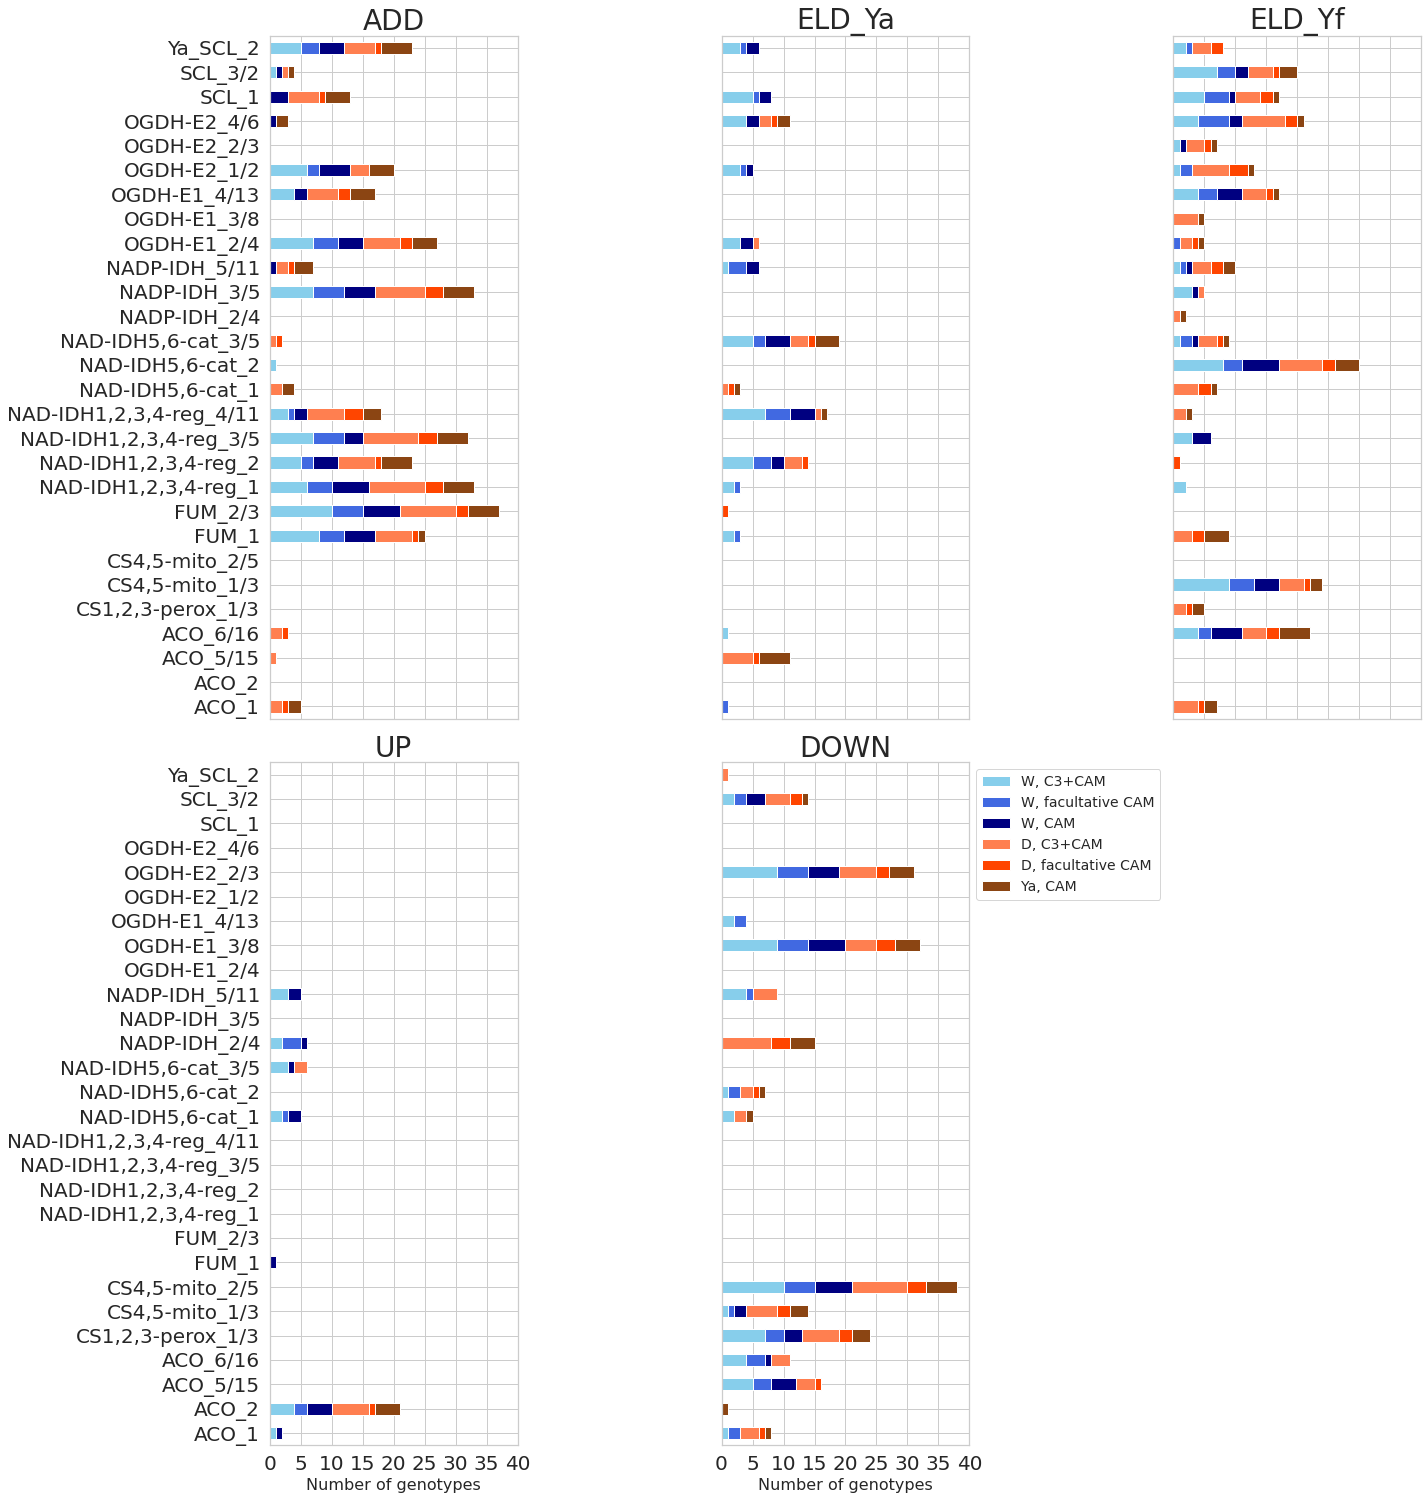

In [54]:
plot_pathway("CA-cycle")

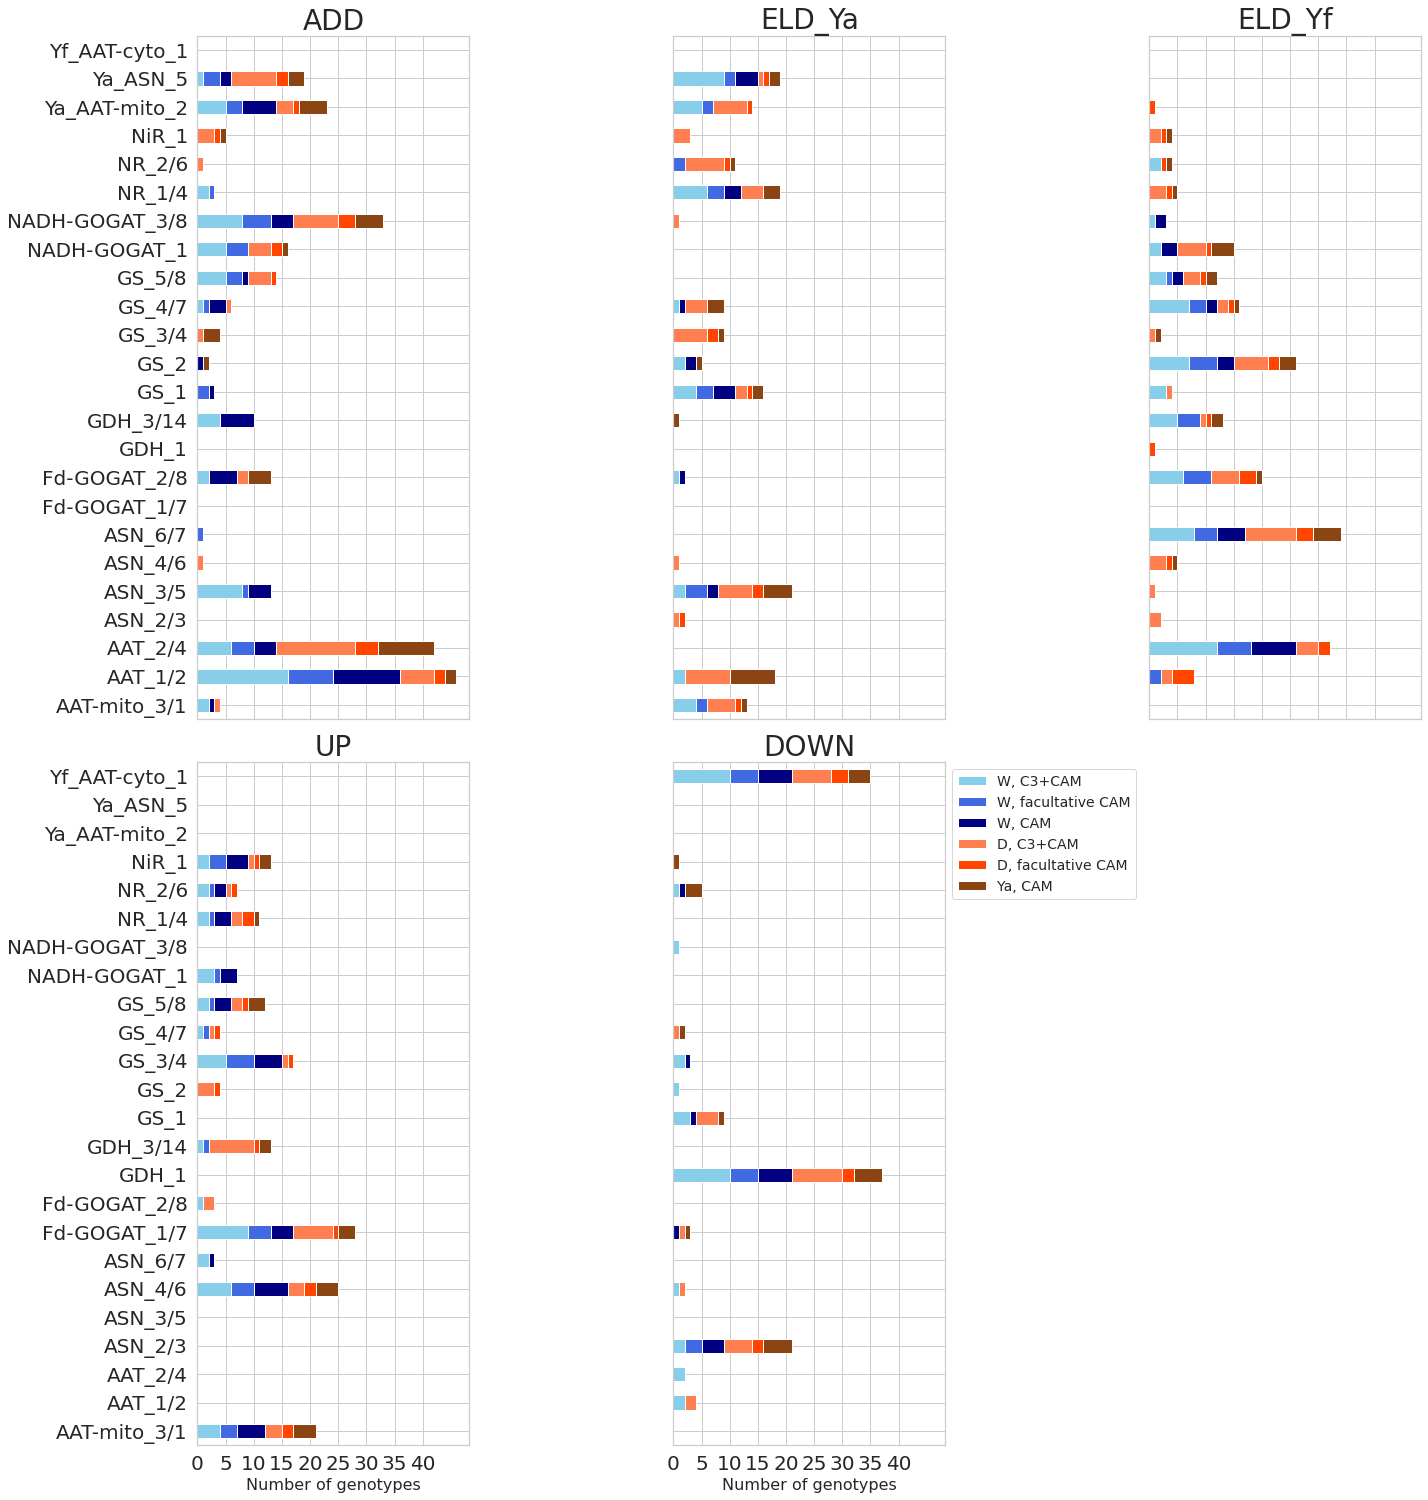

In [55]:
plot_pathway("N-metab")